## Aggregation

### Motivation

 - Publish aggregate data (count, sum, mean, etc.)
 - It might be enough for applications
 - Release less information
 
 Is there any concern?

## Model

**Curator:**
 - Has access to the data.
 - Runs the privacy mechanism (algorithm) to answer queries.

**Data analyst:**
 - Receives the responses to queries.
 - Tries to squeeze out privacy-compromising information about individuals.

|           -        | Secure cryptosystem            | Private data analysis | 
|--------------------|--------------------------------|-----------------------|
|Participants        | Sender, Receiver, Eavesdropper | Curator, Analyst      |
|Owner of information| Sender                         | Curator               |
|Sends information to| Receiver                       | Analyst               |
|Protect against     | Eavesdropper                   | Analyst               |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
adult = pd.read_csv("data.csv")
adult.head(10)

,Name,First Name,Last Name,Sex,SSN,DOB,Birthday,Age,Zip,Education,Marital Status,Occupation,Salary
0,Jason Ortiz,Jason,Ortiz,Male,239-62-5065,12/24/65,12/24,58,55813,Bachelors degree,Widowed,Engineer/ production,Under 25k
1,Anna Brown,Anna,Brown,Female,860-48-3325,03/21/99,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
2,Kevin Anderson,Kevin,Anderson,Male,176-24-2913,05/11/67,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
3,Patricia Clarke,Patricia,Clarke,Female,384-30-3488,12/23/76,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
4,Robert Watson,Robert,Watson,Male,066-16-3817,04/08/01,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k
5,Joseph Carrillo,Joseph,Carrillo,Male,426-75-3893,12/23/88,12/23,35,60983,Masters degree,Never married,Designer/ multimedia,100k to 200k
6,Molly Rodriguez,Molly,Rodriguez,Female,610-28-1657,07/24/88,07/24,36,83909,Bachelors degree,Married,Theatre director,Under 25k
7,Kenneth Smith,Kenneth,Smith,Male,521-01-8305,04/14/02,04/14,22,90525,High school/GED,Never married,Oceanographer,50k to 100k
8,Andrea Hale,Andrea,Hale,Female,586-74-2173,10/27/97,10/27,26,16072,Associate degree,Never married,Solicitor,50k to 100k
9,Tamara Reyes,Tamara,Reyes,Female,034-40-4605,11/04/93,11/04,30,17275,High school/GED,Married,Adult nurse,25k to 50k


We want to learn the average age of people with certain degrees. 

In [3]:
adult[['Education','Age']].groupby('Education', as_index = False).mean().head()

,Education,Age
0,Associate degree,41.234208
1,Bachelors degree,40.830297
2,Doctorate,41.073491
3,High school/GED,41.046953
4,Masters degree,41.228198


If aggregated over a large group, it hides single values.

If aggregated over a group of one person, it reveals the exact age!

In [4]:
adult[['Zip', 'Age']].groupby('Zip', as_index=False).mean().head()

,Zip,Age
0,506,36.0
1,509,53.0
2,519,33.0
3,527,56.0
4,536,56.0


 - The US Census Bureau releases aggregate statistics at the block level.
 - Some blocks have a large population
 - Some blocks have a population of zero.
 - Aggregate data for blocks with a small population might reveal sensitive information.

### How big a group should be?

 - No real answer!
 - Depends on the data
 - Depends on the attack

## Differencing Attacks

**Problem: Release of multiple aggregate statistics.**

Consider the two following summation queries.

In [5]:
adult['Age'].sum()

820400

In [6]:
adult[adult['Name'] != 'Anna Brown']['Age'].sum()

820375

In [7]:
adult['Age'].sum() - adult[adult['Name'] != 'Anna Brown']['Age'].sum()

25

The same problem arises if we ask *How many people in the database have a salary in the range 100k to 200k?*

### What have we learned?

- The security of aggregate data depends on previously released information.
- Releasing useful data makes ensuring privacy complicated.
- Distinguishing between malicious and non-malicious queries is not possible.


## Differential Privacy

### Differential Privacy

 - It is a mathematical definition.
 - Property of an algorithm (a query).
 - A dataset is differentially private if the algorithm that produced it satisfies differential privacy.

### Informal definition

An algorithm is differentially private if, by examining the output, one cannot determine whether any individual's data was included in the original dataset.

The analyst knows no more about any individual in the data after the analysis is completed than she knew before the analysis was begun.

### Distance of datasets

Define the distance of two datasets, $D$ and $D′$, as the number of rows/records they differ. Let $𝑑(D,D′)$ denote the distance between $D$ and $D′$.

The distance/difference can be measure two ways:
 - The number of rows to add to and remove from $D$ to get $D'$. In the example, $d(D,D') = 2$.
 - The number of rows to change, add or reomove to get $D'$ from $D$. In the example, $d(D,D') = 1$.
We use the second definition.

In [8]:
adult.iloc[[0,2,3,4]]

,Name,First Name,Last Name,Sex,SSN,DOB,Birthday,Age,Zip,Education,Marital Status,Occupation,Salary
0,Jason Ortiz,Jason,Ortiz,Male,239-62-5065,12/24/65,12/24,58,55813,Bachelors degree,Widowed,Engineer/ production,Under 25k
2,Kevin Anderson,Kevin,Anderson,Male,176-24-2913,05/11/67,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
3,Patricia Clarke,Patricia,Clarke,Female,384-30-3488,12/23/76,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
4,Robert Watson,Robert,Watson,Male,066-16-3817,04/08/01,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k


In [9]:
adult.iloc[1:5]

,Name,First Name,Last Name,Sex,SSN,DOB,Birthday,Age,Zip,Education,Marital Status,Occupation,Salary
1,Anna Brown,Anna,Brown,Female,860-48-3325,03/21/99,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
2,Kevin Anderson,Kevin,Anderson,Male,176-24-2913,05/11/67,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
3,Patricia Clarke,Patricia,Clarke,Female,384-30-3488,12/23/76,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
4,Robert Watson,Robert,Watson,Male,066-16-3817,04/08/01,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k


### Neighboring dataset and informal DP

 - Two datasets ($D$ and $D'$) are neighboring if $d(D,D')=1$, that is, they differ in the data of a single individual. 
 - Informal DP:

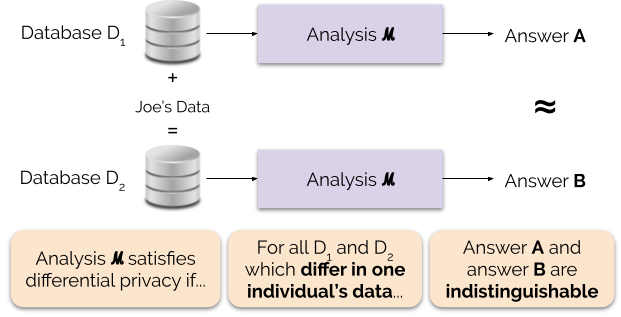

### k-anonimity does not satisfy DP

Name | Alice | Bob | Cloe | Daniel | Eve | Freddie | George | Harry | Ian | Jane
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
Age | 25 | 28 | 31 | 36 | 26 | 33 | 36 | 45 | 41 | 37
Has diabetes | Yes | No | No | Yes | No | Yes | No | No | Yes | Yes

2-anonymized table

Age | 20-30 | 20-30 | 20-30 | 30-40 | 30-40 | 30-40 | 30-40 | 30-40 | 40+ | 40+
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
Has diabetes | Yes | No | No | Yes | Yes | Yes| No | No | Yes | No 

Neighbor dataset: We changed Jane to Julia:

Name | Alice | Bob | Cloe | Daniel | Eve | Freddie | George | Harry | Ian | Julia
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
Age | 25 | 28 | 31 | 36 | 26 | 33 | 36 | 45 | 41 | 22
Has diabetes | Yes | No | No | Yes | No | Yes | No | No | Yes | No

2-anonymized table

Age | 20-30 | 20-30 | 20-30 | 20-30 | 30-40 | 30-40 | 30-40 | 30-40 | 40+ | 40+
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
Has diabetes | Yes | No | No | No | Yes | Yes| No | No | Yes | No 

The number of people whos age is between 20-30 and 30-40 changed, therefore it is possible to distinguish between the two datasets.

### Definition

 > A randomized algorithm $M$ is $\varepsilon$-differentially private if for all neighboring datasets $D$ and $D'$ and all possible sets of output $S$, $$\frac{\Pr[M(D) \in S]}{\Pr[M(D') \in S]} \le e^\varepsilon $$
 
 The algorithm produces a different output for neighboring datasets with only a small probability.
 

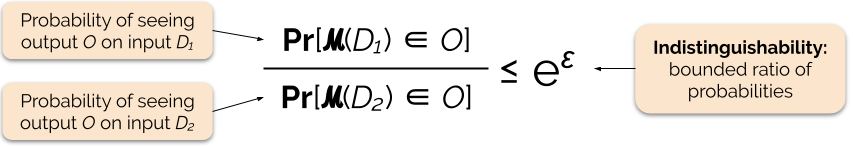

### The parameter $\varepsilon$

 - $\varepsilon$ is the privacy parameter/privacy budget. It tunes the amount of privacy the definition provides.
      - Small $\varepsilon \Rightarrow$ more privacy.
      - Large $\varepsilon \Rightarrow$ less privacy.

### Discrete Distributions

> Suppose the range (output) of $M$ is a discrete (finite) set (e.g., integers, 32-bit floating-point numbers, marital status, etc.), In that case, the definition can consider $S$ to be a single value (e.g., 37, married, etc.). Then we can write $M(D) = S$ instead of $M(D) \in S$ the inequality:
$$ \frac{\Pr[M(D) = S]}{\Pr[M(D') = S]} \le e^\varepsilon $$

### How do we acheive differential privacy?

 - Add noise to the outcome of the algorithm.
 - Randomize response - lie about the answer with some probability

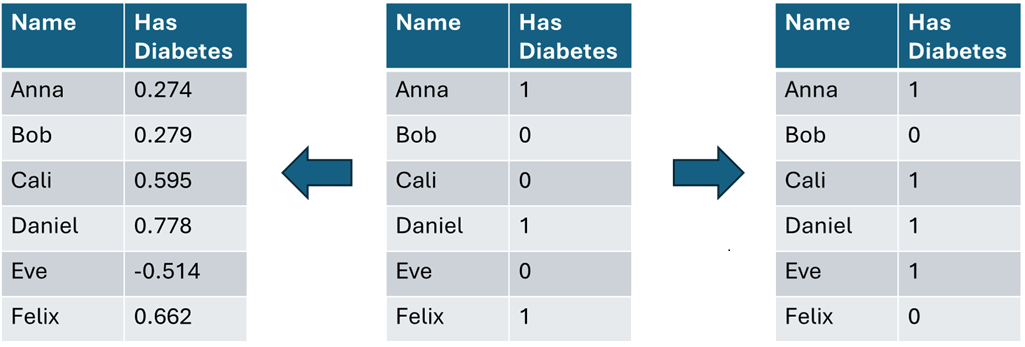

## Laplace mechanism

### Laplace distribution

Properties:
 - *double exponential* distribution
 - Laplace distribution has two parameters
 - $\mu$: mean (or location), $b > 0$: scale (or diversity)
 - If $\mu=0$ and $b=1$, the positive half-line is exactly an exponential distribution scaled by 1/2.
 
$Lap(t)$ denotes sampling from the Laplace distribution with *location/mean = 0* and *scale t*.

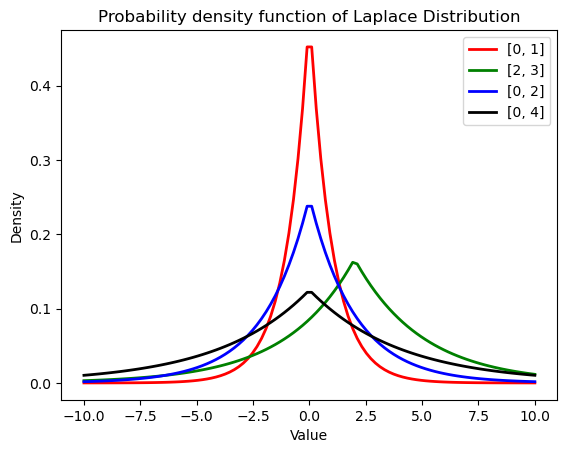

In [10]:
# Step 1: Parameters: loc is the location parameter (mean), scale is the scale parameter (variance)
mean = [0, 2, 0, 0]    # mean (location)
scale = [1, 3, 2, 4]   # scale (diversity)
color = ['r', 'g', 'b', 'k']

# Step 2: Plot the Laplace distribution
x = np.linspace(-10, 10, 100)
for i in range(4):
    pdf = (1/(2*scale[i])) * np.exp(-np.abs(x-mean[i])/scale[i])
    plt.plot(x, pdf, color[i], label = [mean[i], scale[i]], linewidth=2)

plt.title('Probability density function of Laplace Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

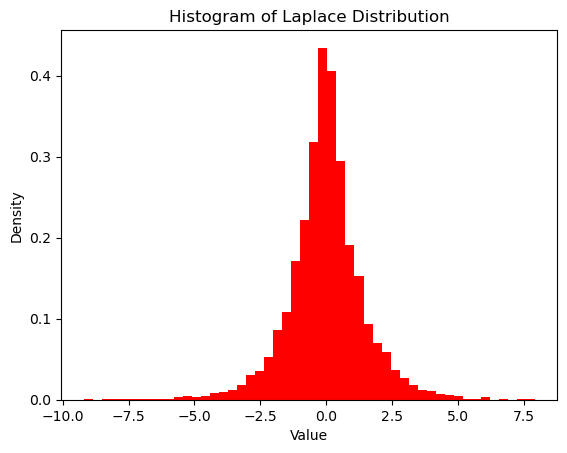

In [11]:
# Step 1: Generate random samples from a Laplace distribution
# Parameters: loc is the location parameter (mean), scale is the scale parameter (variance)
mean = 0    # mean (location)
scale = 1   # scale (diversity)

# Generate 10000 random samples from the Laplace distribution
data = np.random.laplace(loc=mean, scale=scale, size=10000)

# Step 2: Plot the histogram
plt.hist(data, bins=50, density=True, color='r')

plt.title('Histogram of Laplace Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

### Sensitivity

 - The amount of the function's output can change if the input changes.
 - Let $f: \mathcal{D} \rightarrow \mathbb{R}$ be a function. Then $$S(f) = \max_{x,x':d(x,x')\le 1} |f(x) - f(x')|$$
 - If $f$ is a count query, then $S(f) = 1$.
 - If $f$ is the age sum query, then $S(f)$ is the maximal possible age of an individual.
 - It is often challenging to compute the sensitivity. We will discuss this later.

### Laplace mechanism

Let $f$ be a function that returns a number. Defy $M$ the following way: $$ M(x) = f(x) + Lap\left(\frac{S(f)}{\varepsilon}\right).$$

If $f$ is a count query, then $$ M(x) = f(x) + Lap\left(\frac{1}{\varepsilon}\right).$$

> **Theorem:** The Laplace mechanism preserves $\varepsilon$-differential privacy.

### Example

We want to know the number of individuals with age at least 40.

In [12]:
adult[adult['Age'] >= 40].shape[0]

10650

In [13]:
sensitivity = 1
epsilon = 0.1

adult[adult['Age'] >= 40].shape[0] + np.random.laplace(loc=0, scale=sensitivity/epsilon)

10666.124388046539

### Example 2

We test Laplace-mechanism for a query that would result in 1.

In [14]:
jasons_row = adult[adult['Name'] == 'Jason Ortiz']
jasons_row[jasons_row['Salary'] == 'Under 25k'].shape[0]

1

In [15]:
sensitivity = 1
epsilon = 0.1

jasons_row = adult[adult['Name'] == 'Jason Ortiz']
jasons_row[jasons_row['Salary'] == 'Under 25k'].shape[0] + np.random.laplace(loc=0, scale=sensitivity/epsilon)

-11.353425196239424

Let's experiment with different values of $\varepsilon$!

In [58]:
epsilon = 0.1
jasons_row[jasons_row['Salary'] == 'Under 25k'].shape[0] + np.random.laplace(loc=0, scale=sensitivity/epsilon)

7.493778710418077

In [57]:
epsilon = 1
jasons_row[jasons_row['Salary'] == 'Under 25k'].shape[0] + np.random.laplace(loc=0, scale=sensitivity/epsilon)

-1.994190517039208

In [81]:
epsilon = 10
jasons_row[jasons_row['Salary'] == 'Under 25k'].shape[0] + np.random.laplace(loc=0, scale=sensitivity/epsilon)

1.0062021258847893

In [100]:
epsilon = 100
jasons_row[jasons_row['Salary'] == 'Under 25k'].shape[0] + np.random.laplace(loc=0, scale=sensitivity/epsilon)

1.0153916073164768

### Summary:
 - Differential privacy can protect individuals in a dataset.   
 - Laplace mechanism can provide DP.
 - The level of privacy depends on the parameter $\varepsilon$.
 - Small values of $\varepsilon$ provide more privacy but have less accuracy.
 - Large values of $\varepsilon$ provide less privacy but are more accurate.

## Compositions of DP

### Sequential Composition

We saw that releasing multiple queries of the same data violates privacy for aggregations. Does DP provide privacy?

> Theorem (Sequential Composition):
>    - $M_1$ and $M_2$ are two mechanisms.
>    - If $M_1$ satisfies $\varepsilon_1$-differential privacy, and $M_2$ satisfies $\varepsilon_2$-differential privacy, then the mechanism $M = (M_1,M_2)$ which releases both results, satisfies $\varepsilon_1 + \varepsilon_2$-differential privacy.

 - We can ask for queries from the same dataset multiple times. The result is still DP but with a larger $\varepsilon$ (less private).
 - The given privacy budget is upper bound so that the actual privacy cost may be smaller.

Let's try the differencing attack! With the choice $\varepsilon = 0.5$, the final result satisfies 1-DP. 

In [109]:
epsilon = 0.5
numb1 = adult[adult['Salary'] == 'Under 25'].shape[0] + np.random.laplace(loc=0, scale=1/epsilon)
adult_no_jason = adult[adult['Name'] != 'Jason Ortiz']
numb2 = adult_no_jason[adult_no_jason['Salary'] == 'Under 25'].shape[0] + np.random.laplace(loc=0, scale=1/epsilon)
numb1 - numb2

2.586374970541897

### Privacy cost of the sequential composition

We will examine the privacy cost of the sequential composition on a simple example.

In [21]:
epsilon1 = 1
epsilon2 = 1
epsilon_total = 2

# satisfies 1-differential privacy
def F1():
    return np.random.laplace(loc=0, scale=1/epsilon1)

# satisfies 1-differential privacy
def F2():
    return np.random.laplace(loc=0, scale=1/epsilon2)

# satisfies 2-differential privacy
def F3():
    return np.random.laplace(loc=0, scale=1/epsilon_total)

# satisfies 2-differential privacy, by sequential composition
def F_combined():
    return (F1() + F2()) / 2

The graph F1 and F2 looks pretty similar, because they are generated by the same distribution.

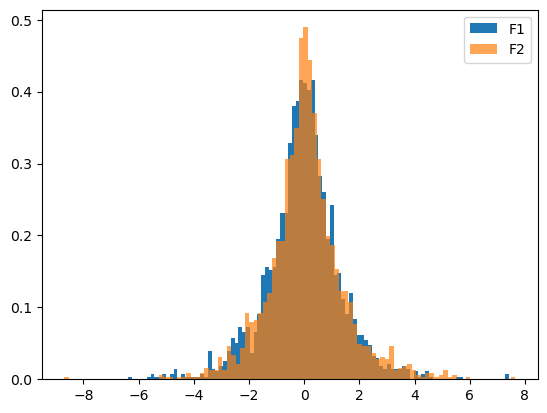

In [111]:
# plot F1
plt.hist([F1() for i in range(2000)], bins=100, label='F1', density = True);

# plot F2 (should look the same)
plt.hist([F2() for i in range(2000)], bins=100, alpha=.7, label='F2', density = True);
plt.legend();

The graph **F3** looks *pointier*. It is not a surprise, as the scale is smaller. Therefore **F3** provide less privacy than **F1**, which is exactly what we were expecting from a higher value of $\varepsilon$. 

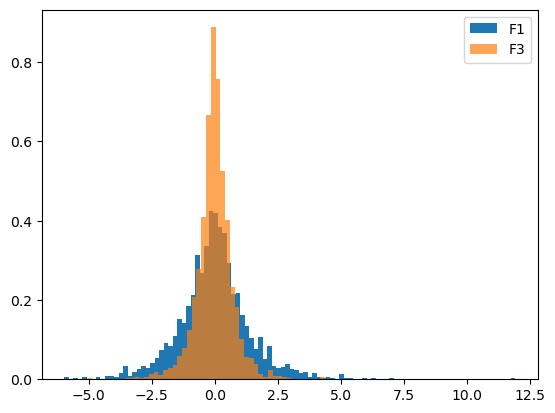

In [112]:
# plot F1
plt.hist([F1() for i in range(2000)], bins=100, label='F1', density = True);

# plot F3 (should look "pointier")
plt.hist([F3() for i in range(2000)], bins=50, alpha=.7, label='F3', density = True);
plt.legend();

The graph **F_combined** is a little bit *pointier*, therefore it provide less privacy than **F_1**. This is coincide with our expectation.

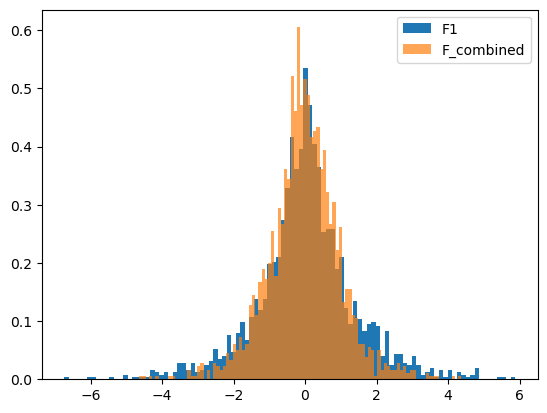

In [116]:
# plot F1
plt.hist([F1() for i in range(2000)], bins=100, label='F1', density = True);

# plot F_combined (should look "pointier")
plt.hist([F_combined() for i in range(2000)], bins=100, alpha=.7, label='F_combined', density = True);
plt.legend();


The graph **F3** is *pointier*, therefore it provides less privacy. The privacy budget for both **F3** and **F_combined** is 2, so why is there a difference? The reason that the 2 is an upper bound for the privacy cost for **F_combined**, the actual cumulative impact on privacy is lower.  

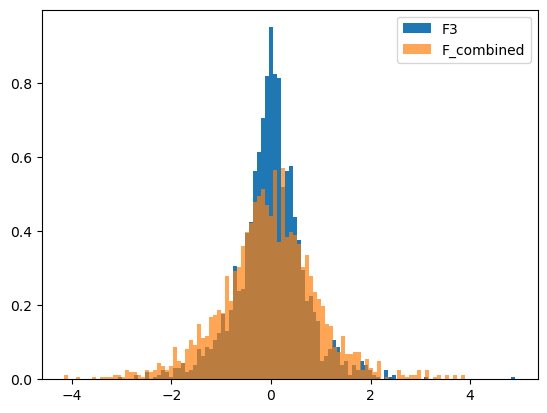

In [119]:
# plot F1
plt.hist([F3() for i in range(2000)], bins=100, label='F3', density = True);

# plot F_combined (should look "pointier")
plt.hist([F_combined() for i in range(2000)], bins=100, alpha=.7, label='F_combined', density = True);
plt.legend();